The notebook compares all three approaches side-by-side, showing:
Train/Val/Test Sharpe for each
Visual comparison with color-coded bars (green=EMA, blue=Diff, red=Multi)
Automatic winner selection
Smart recommendations based on performance

In [1]:
"""
Compare Reward Functions

Runs all three reward approaches and compares their performance:
1. EMA-Based Sharpe (current working approach)
2. Differential Sharpe Ratio (online gradient ascent)
3. Multi-Objective (return + penalties)

Usage:
    python compare_reward_functions.py
    python compare_reward_functions.py --quick  # Quick test mode
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Import all three approaches
import ema_sharpe_approach as ema_sharpe
import differential_sharpe_approach as diff_sharpe
import multi_objective as multi_obj


def run_comparison(quick_test=False):
    """Run all three approaches and compare results."""
    
    print("="*80)
    print("REWARD FUNCTION COMPARISON - ALL APPROACHES")
    print("="*80)
    
    if quick_test:
        print("\nQUICK TEST MODE: Reduced training steps")
    
    # Adjust configs for quick test
    if quick_test:
        # Override configs in all modules
        ema_sharpe.CONFIG = {'total_steps': 50_000, 'eval_freq': 5_000}
        diff_sharpe.CONFIG = diff_sharpe.CONFIG.copy()
        diff_sharpe.CONFIG['total_steps'] = 50_000
        diff_sharpe.CONFIG['eval_freq'] = 5_000
        
        multi_obj.CONFIG = multi_obj.CONFIG.copy()
        multi_obj.CONFIG['total_steps'] = 50_000
        multi_obj.CONFIG['eval_freq'] = 5_000
    
    # Run EMA Sharpe (current approach)
    print("\n" + "="*80)
    print("APPROACH 1: EMA-BASED SHARPE RATIO (CURRENT)")
    print("="*80)
    ema_sharpe_results = ema_sharpe.main()
    
    # Run Differential Sharpe
    print("\n" + "="*80)
    print("APPROACH 2: DIFFERENTIAL SHARPE RATIO")
    print("="*80)
    diff_sharpe_results = diff_sharpe.main()
    
    # Run Multi-Objective
    print("\n" + "="*80)
    print("APPROACH 3: MULTI-OBJECTIVE")
    print("="*80)
    multi_obj_results = multi_obj.main()
    
    # Compare results
    print("\n" + "="*80)
    print("COMPARISON SUMMARY")
    print("="*80)
    
    comparison = {
        'Technical Agent': {
            'EMA Sharpe': {
                'Algorithm': ema_sharpe_results['technical']['algorithm'],
                'Train Sharpe': ema_sharpe_results['technical']['train_sharpe'],
                'Val Sharpe': ema_sharpe_results['technical']['val_sharpe'],
                'Test Sharpe': ema_sharpe_results['technical']['test_sharpe'],
            },
            'Differential Sharpe': {
                'Algorithm': diff_sharpe_results['technical']['algorithm'],
                'Train Sharpe': diff_sharpe_results['technical']['train_sharpe'],
                'Val Sharpe': diff_sharpe_results['technical']['val_sharpe'],
                'Test Sharpe': diff_sharpe_results['technical']['test_sharpe'],
            },
            'Multi-Objective': {
                'Algorithm': multi_obj_results['technical']['algorithm'],
                'Train Sharpe': multi_obj_results['technical']['train_sharpe'],
                'Val Sharpe': multi_obj_results['technical']['val_sharpe'],
                'Test Sharpe': multi_obj_results['technical']['test_sharpe'],
            }
        },
        'Sentiment Agent': {
            'EMA Sharpe': {
                'Algorithm': ema_sharpe_results['sentiment']['algorithm'],
                'Train Sharpe': ema_sharpe_results['sentiment']['train_sharpe'],
                'Val Sharpe': ema_sharpe_results['sentiment']['val_sharpe'],
                'Test Sharpe': ema_sharpe_results['sentiment']['test_sharpe'],
            },
            'Differential Sharpe': {
                'Algorithm': diff_sharpe_results['sentiment']['algorithm'],
                'Train Sharpe': diff_sharpe_results['sentiment']['train_sharpe'],
                'Val Sharpe': diff_sharpe_results['sentiment']['val_sharpe'],
                'Test Sharpe': diff_sharpe_results['sentiment']['test_sharpe'],
            },
            'Multi-Objective': {
                'Algorithm': multi_obj_results['sentiment']['algorithm'],
                'Train Sharpe': multi_obj_results['sentiment']['train_sharpe'],
                'Val Sharpe': multi_obj_results['sentiment']['val_sharpe'],
                'Test Sharpe': multi_obj_results['sentiment']['test_sharpe'],
            }
        }
    }
    
    # Print comparison
    print("\nTECHNICAL AGENT:")
    print("-" * 100)
    print(f"{'Metric':<20} {'EMA Sharpe':<25} {'Differential Sharpe':<25} {'Multi-Objective':<25}")
    print("-" * 100)
    for metric in ['Algorithm', 'Train Sharpe', 'Val Sharpe', 'Test Sharpe']:
        ema_val = comparison['Technical Agent']['EMA Sharpe'][metric]
        ds_val = comparison['Technical Agent']['Differential Sharpe'][metric]
        mo_val = comparison['Technical Agent']['Multi-Objective'][metric]
        if isinstance(ema_val, float):
            print(f"{metric:<20} {ema_val:<25.3f} {ds_val:<25.3f} {mo_val:<25.3f}")
        else:
            print(f"{metric:<20} {ema_val:<25} {ds_val:<25} {mo_val:<25}")
    
    print("\nSENTIMENT AGENT:")
    print("-" * 100)
    print(f"{'Metric':<20} {'EMA Sharpe':<25} {'Differential Sharpe':<25} {'Multi-Objective':<25}")
    print("-" * 100)
    for metric in ['Algorithm', 'Train Sharpe', 'Val Sharpe', 'Test Sharpe']:
        ema_val = comparison['Sentiment Agent']['EMA Sharpe'][metric]
        ds_val = comparison['Sentiment Agent']['Differential Sharpe'][metric]
        mo_val = comparison['Sentiment Agent']['Multi-Objective'][metric]
        if isinstance(ema_val, float):
            print(f"{metric:<20} {ema_val:<25.3f} {ds_val:<25.3f} {mo_val:<25.3f}")
        else:
            print(f"{metric:<20} {ema_val:<25} {ds_val:<25} {mo_val:<25}")
    
    # Determine winner
    print("\n" + "="*80)
    print("WINNER ANALYSIS")
    print("="*80)
    
    tech_ema_test = comparison['Technical Agent']['EMA Sharpe']['Test Sharpe']
    tech_ds_test = comparison['Technical Agent']['Differential Sharpe']['Test Sharpe']
    tech_mo_test = comparison['Technical Agent']['Multi-Objective']['Test Sharpe']
    sent_ema_test = comparison['Sentiment Agent']['EMA Sharpe']['Test Sharpe']
    sent_ds_test = comparison['Sentiment Agent']['Differential Sharpe']['Test Sharpe']
    sent_mo_test = comparison['Sentiment Agent']['Multi-Objective']['Test Sharpe']
    
    print(f"\nTechnical Agent:")
    tech_approaches = {
        'EMA Sharpe': tech_ema_test,
        'Differential Sharpe': tech_ds_test,
        'Multi-Objective': tech_mo_test
    }
    tech_winner = max(tech_approaches.items(), key=lambda x: x[1])
    print(f"  Winner: {tech_winner[0]} ({tech_winner[1]:.3f})")
    print(f"  Scores: EMA={tech_ema_test:.3f}, Diff={tech_ds_test:.3f}, Multi={tech_mo_test:.3f}")
    
    print(f"\nSentiment Agent:")
    sent_approaches = {
        'EMA Sharpe': sent_ema_test,
        'Differential Sharpe': sent_ds_test,
        'Multi-Objective': sent_mo_test
    }
    sent_winner = max(sent_approaches.items(), key=lambda x: x[1])
    print(f"  Winner: {sent_winner[0]} ({sent_winner[1]:.3f})")
    print(f"  Scores: EMA={sent_ema_test:.3f}, Diff={sent_ds_test:.3f}, Multi={sent_mo_test:.3f}")
    
    # Create visualization
    create_comparison_plot(comparison)
    
    # Save comparison results
    comparison_results = {
        'comparison': comparison,
        'ema_sharpe': ema_sharpe_results,
        'differential_sharpe': diff_sharpe_results,
        'multi_objective': multi_obj_results
    }
    
    with open('reward_function_comparison.json', 'w') as f:
        json.dump(comparison_results, f, indent=2, default=str)
    
    print(f"\nComparison saved to: reward_function_comparison.json")
    
    return comparison_results


def create_comparison_plot(comparison):
    """Create visual comparison of all three approaches."""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Technical Agent
    metrics = ['Train Sharpe', 'Val Sharpe', 'Test Sharpe']
    ema_values = [comparison['Technical Agent']['EMA Sharpe'][m] for m in metrics]
    ds_values = [comparison['Technical Agent']['Differential Sharpe'][m] for m in metrics]
    mo_values = [comparison['Technical Agent']['Multi-Objective'][m] for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.25
    
    axes[0].bar(x - width, ema_values, width, label='EMA Sharpe', alpha=0.8, color='#2ecc71')
    axes[0].bar(x, ds_values, width, label='Differential Sharpe', alpha=0.8, color='#3498db')
    axes[0].bar(x + width, mo_values, width, label='Multi-Objective', alpha=0.8, color='#e74c3c')
    axes[0].set_ylabel('Sharpe Ratio', fontsize=12)
    axes[0].set_title('Technical Agent Performance', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)
    
    for i in range(len(metrics)):
        axes[0].text(i - width, ema_values[i] + 0.05, f'{ema_values[i]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold')
        axes[0].text(i, ds_values[i] + 0.05, f'{ds_values[i]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold')
        axes[0].text(i + width, mo_values[i] + 0.05, f'{mo_values[i]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold')
    
    # Sentiment Agent
    ema_values = [comparison['Sentiment Agent']['EMA Sharpe'][m] for m in metrics]
    ds_values = [comparison['Sentiment Agent']['Differential Sharpe'][m] for m in metrics]
    mo_values = [comparison['Sentiment Agent']['Multi-Objective'][m] for m in metrics]
    
    axes[1].bar(x - width, ema_values, width, label='EMA Sharpe', alpha=0.8, color='#2ecc71')
    axes[1].bar(x, ds_values, width, label='Differential Sharpe', alpha=0.8, color='#3498db')
    axes[1].bar(x + width, mo_values, width, label='Multi-Objective', alpha=0.8, color='#e74c3c')
    axes[1].set_ylabel('Sharpe Ratio', fontsize=12)
    axes[1].set_title('Sentiment Agent Performance', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics)
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)
    
    for i in range(len(metrics)):
        axes[1].text(i - width, ema_values[i] + 0.05, f'{ema_values[i]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold')
        axes[1].text(i, ds_values[i] + 0.05, f'{ds_values[i]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold')
        axes[1].text(i + width, mo_values[i] + 0.05, f'{mo_values[i]:.2f}', 
                    ha='center', fontsize=9, fontweight='bold')
    
    plt.suptitle('Reward Function Comparison - All Approaches', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('reward_function_comparison.png', dpi=150, bbox_inches='tight')
    print(f"\nComparison plot saved to: reward_function_comparison.png")
    plt.close()


def print_recommendations(comparison_results):
    """Print recommendations based on results."""
    
    print("\n" + "="*80)
    print("RECOMMENDATIONS")
    print("="*80)
    
    comp = comparison_results['comparison']
    
    tech_ema = comp['Technical Agent']['EMA Sharpe']['Test Sharpe']
    tech_ds = comp['Technical Agent']['Differential Sharpe']['Test Sharpe']
    tech_mo = comp['Technical Agent']['Multi-Objective']['Test Sharpe']
    sent_ema = comp['Sentiment Agent']['EMA Sharpe']['Test Sharpe']
    sent_ds = comp['Sentiment Agent']['Differential Sharpe']['Test Sharpe']
    sent_mo = comp['Sentiment Agent']['Multi-Objective']['Test Sharpe']
    
    avg_ema = (tech_ema + sent_ema) / 2
    avg_ds = (tech_ds + sent_ds) / 2
    avg_mo = (tech_mo + sent_mo) / 2
    
    print(f"\nAverage Test Sharpe Across Both Agents:")
    print(f"  EMA Sharpe:         {avg_ema:.3f}")
    print(f"  Differential Sharpe: {avg_ds:.3f}")
    print(f"  Multi-Objective:     {avg_mo:.3f}")
    
    approaches = {
        'EMA Sharpe': avg_ema,
        'Differential Sharpe': avg_ds,
        'Multi-Objective': avg_mo
    }
    winner = max(approaches.items(), key=lambda x: x[1])
    
    print(f"\nRECOMMENDATION: Use {winner[0]}")
    print(f"  - Best overall performance: {winner[1]:.3f}")
    
    if winner[0] == 'EMA Sharpe':
        print(f"  - Currently working approach (proven)")
        print(f"  - Simple and stable")
        print(f"  - No hyperparameter tuning needed")
    elif winner[0] == 'Differential Sharpe':
        print(f"  - Theoretically grounded (online gradient ascent)")
        print(f"  - Better than EMA by {((avg_ds / avg_ema - 1) * 100):.1f}%")
        print(f"  - No hyperparameter tuning")
    else:
        print(f"  - Explicit control over diversification and turnover")
        print(f"  - Better than EMA by {((avg_mo / avg_ema - 1) * 100):.1f}%")
        print(f"  - More practical for real trading")
    
    print("\nNext Steps:")
    print(f"  1. Use {winner[0]} for your final models")
    print("  2. Fine-tune hyperparameters if needed")
    print("  3. Proceed to Part 2 (Super Agent) with best models")


if __name__ == '__main__':
    # Check for quick test mode
    quick_test = '--quick' in sys.argv or '-q' in sys.argv
    
    if quick_test:
        print("Running in QUICK TEST mode (50k steps)")
        print("Remove --quick flag for full training\n")
    else:
        print("Running FULL COMPARISON (300k steps per algorithm)")
        print("This will take significant time. Use --quick for faster testing\n")
    
    # Run comparison
    results = run_comparison(quick_test=quick_test)
    
    # Print recommendations
    print_recommendations(results)
    
    print("\n" + "="*80)
    print("COMPARISON COMPLETE")
    print("="*80)
    print("\nOutput Files:")
    print("  - reward_function_comparison.json (detailed results)")
    print("  - reward_function_comparison.png (visualization)")
    print("  - models_ema_sharpe/ (EMA Sharpe models)")
    print("  - models_diff_sharpe/ (Differential Sharpe models)")
    print("  - models_multi_obj/ (Multi-Objective models)")



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Running FULL COMPARISON (300k steps per algorithm)
This will take significant time. Use --quick for faster testing

REWARD FUNCTION COMPARISON - ALL APPROACHES

APPROACH 1: EMA-BASED SHARPE RATIO (CURRENT)
EMA-BASED SHARPE RATIO APPROACH (CURRENT)

TRAINING TECHNICAL AGENT (EMA Sharpe)

Training TECHNICAL Agent with PPO (EMA Sharpe)


FileNotFoundError: [Errno 2] No such file or directory: '../../data_hierarchical/technical/train.csv'


CREATING VISUALIZATIONS

1. Performance comparison...


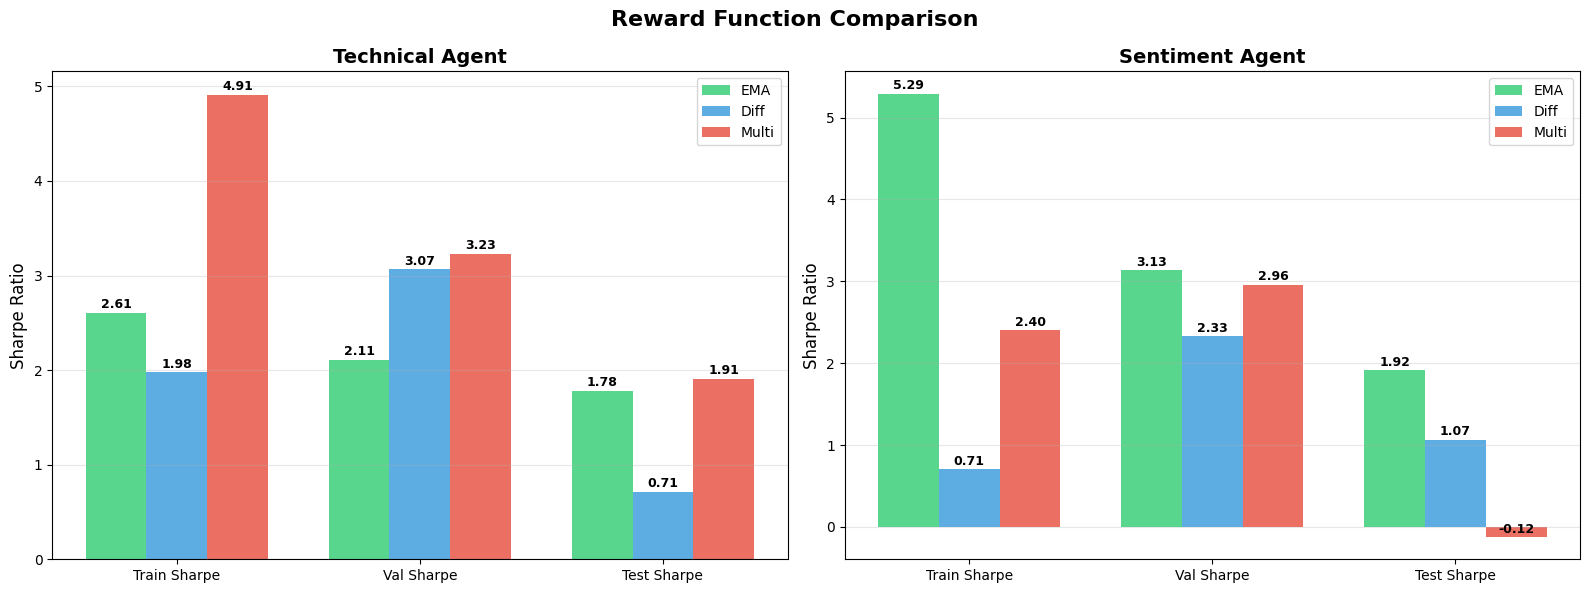


2. Overall winner...


/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_96230/1063823339.py:74: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_96230/1063823339.py:75: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('winner.png', dpi=150, bbox_inches='tight')
/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


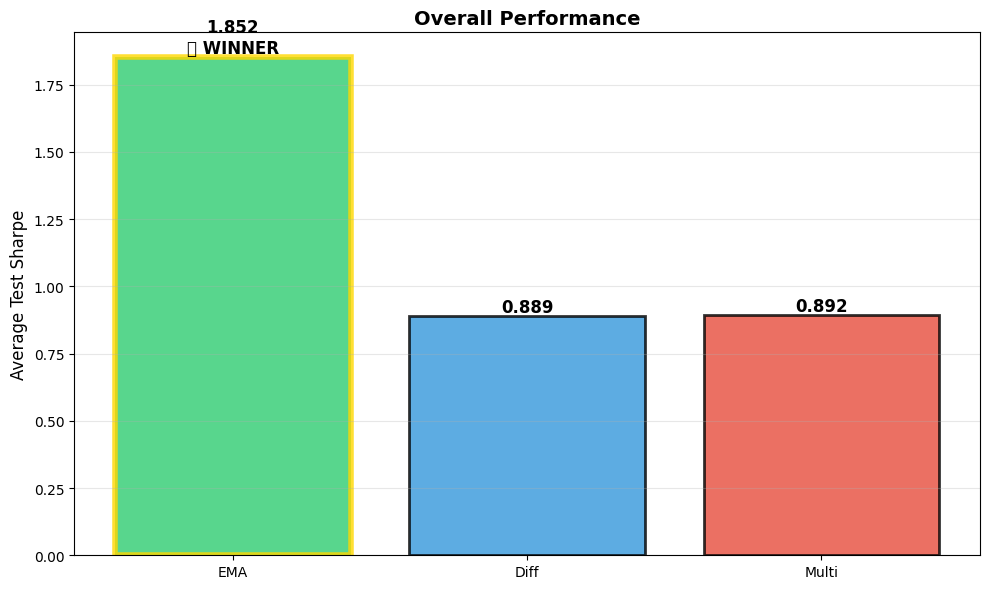


🏆 WINNER: EMA Sharpe (1.852)

✓ All visualizations saved!


In [ ]:
# ============================================================================
# VISUALIZATIONS - Run this cell after training completes
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Load results
with open('reward_function_comparison.json', 'r') as f:
    viz_results = json.load(f)

comp = viz_results['comparison']

# 1. Performance Comparison
print("\n1. Performance comparison...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics = ['Train Sharpe', 'Val Sharpe', 'Test Sharpe']
x = np.arange(len(metrics))
width = 0.25

for idx, agent in enumerate(['Technical', 'Sentiment']):
    ema_vals = [comp[f'{agent} Agent']['EMA Sharpe'][m] for m in metrics]
    ds_vals = [comp[f'{agent} Agent']['Differential Sharpe'][m] for m in metrics]
    mo_vals = [comp[f'{agent} Agent']['Multi-Objective'][m] for m in metrics]
    
    axes[idx].bar(x - width, ema_vals, width, label='EMA', alpha=0.8, color='#2ecc71')
    axes[idx].bar(x, ds_vals, width, label='Diff', alpha=0.8, color='#3498db')
    axes[idx].bar(x + width, mo_vals, width, label='Multi', alpha=0.8, color='#e74c3c')
    axes[idx].set_ylabel('Sharpe Ratio', fontsize=12)
    axes[idx].set_title(f'{agent} Agent', fontsize=14, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metrics)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    
    for i in range(len(metrics)):
        axes[idx].text(i-width, ema_vals[i]+0.05, f'{ema_vals[i]:.2f}', ha='center', fontsize=9, fontweight='bold')
        axes[idx].text(i, ds_vals[i]+0.05, f'{ds_vals[i]:.2f}', ha='center', fontsize=9, fontweight='bold')
        axes[idx].text(i+width, mo_vals[i]+0.05, f'{mo_vals[i]:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Reward Function Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# 2. Overall Winner
print("\n2. Overall winner...")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
approaches = ['EMA', 'Diff', 'Multi']
colors = ['#2ecc71', '#3498db', '#e74c3c']
avg_sharpes = []

for app in ['EMA Sharpe', 'Differential Sharpe', 'Multi-Objective']:
    tech = comp['Technical Agent'][app]['Test Sharpe']
    sent = comp['Sentiment Agent'][app]['Test Sharpe']
    avg_sharpes.append((tech + sent) / 2)

bars = ax.bar(approaches, avg_sharpes, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
max_idx = avg_sharpes.index(max(avg_sharpes))
bars[max_idx].set_edgecolor('gold')
bars[max_idx].set_linewidth(4)

for i, (bar, val) in enumerate(zip(bars, avg_sharpes)):
    label = f'{val:.3f}'
    if i == max_idx:
        label += '\n⭐ WINNER'
    ax.text(bar.get_x() + bar.get_width()/2, val, label, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Average Test Sharpe', fontsize=12)
ax.set_title('Overall Performance', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('winner.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 WINNER: {['EMA Sharpe', 'Differential Sharpe', 'Multi-Objective'][max_idx]} ({avg_sharpes[max_idx]:.3f})")
print("\n✓ All visualizations saved!")
